In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
zip_path = r"C:\Users\ADMIN\Downloads\archive (1).zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")

Dataset extracted


In [4]:
labels = pd.read_csv(r"dataset/dataset/labels.csv")
labels.head()

,name,category,type,grade
0,1.jpg,0,4,3
1,2.jpg,0,4,3
2,3.jpg,0,2,2
3,4.jpg,0,2,1
4,5.jpg,0,1,3


In [5]:
image_folder = r"dataset/dataset/images/"
labels["image_path"] = image_folder + labels["name"]

labels.head()

,name,category,type,grade,image_path
0,1.jpg,0,4,3,dataset/dataset/images/1.jpg
1,2.jpg,0,4,3,dataset/dataset/images/2.jpg
2,3.jpg,0,2,2,dataset/dataset/images/3.jpg
3,4.jpg,0,2,1,dataset/dataset/images/4.jpg
4,5.jpg,0,1,3,dataset/dataset/images/5.jpg


In [6]:
labels["label"] = labels["category"]

In [7]:
train_df, test_df = train_test_split(
    labels,
    test_size=0.2,
    random_state=42
)

In [8]:
IMG_SIZE = (128,128)
BATCH_SIZE = 32

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw"
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 569 validated image filenames.
Found 143 validated image filenames.


In [11]:
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1)
])

In [12]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 128)       0

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
18/18 [==============================] - 90s 4s/step - loss: 1.3166 - mae: 0.8070 - val_loss: 0.4858 - val_mae: 0.5925
Epoch 2/50
18/18 [==============================] - 74s 4s/step - loss: 0.6005 - mae: 0.6412 - val_loss: 0.4562 - val_mae: 0.5779
Epoch 3/50
18/18 [==============================] - 92s 5s/step - loss: 0.5104 - mae: 0.6030 - val_loss: 0.3776 - val_mae: 0.5313
Epoch 4/50
18/18 [==============================] - 57s 3s/step - loss: 0.4371 - mae: 0.5308 - val_loss: 0.3125 - val_mae: 0.4467
Epoch 5/50
18/18 [==============================] - 59s 3s/step - loss: 0.4413 - mae: 0.5319 - val_loss: 0.3031 - val_mae: 0.4460
Epoch 6/50
18/18 [==============================] - 54s 3s/step - loss: 0.4047 - mae: 0.5123 - val_loss: 0.3205 - val_mae: 0.4822
Epoch 7/50
18/18 [==============================] - 57s 3s/step - loss: 0.4115 - mae: 0.5197 - val_loss: 0.3029 - val_mae: 0.4616
Epoch 8/50
18/18 [==============================] - 79s 4s/step - loss: 0.3902 - mae: 0.50

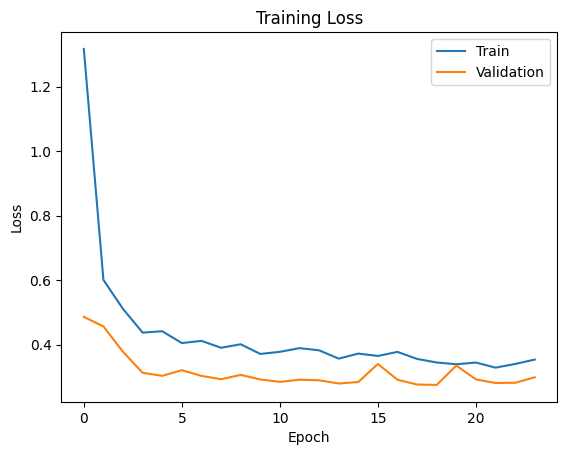

In [16]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [17]:
loss, mae = model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test MAE:", mae)

5/5 [==============================] - 16s 3s/step - loss: 0.2749 - mae: 0.4048
Test Loss: 0.2749011516571045
Test MAE: 0.4048272669315338


In [18]:
predictions = model.predict(test_generator)

print(predictions[:10])

5/5 [==============================] - 14s 2s/step
[[0.44751352]
 [0.61528456]
 [0.46985978]
 [0.13891615]
 [0.6953237 ]
 [1.142744  ]
 [0.39755595]
 [0.38320476]
 [1.0111172 ]
 [0.4248222 ]]


In [31]:

pip install gradio==3.50.2

  Using cached gradio-3.50.2-py3-none-any.whl.metadata (17 kB)
  Using cached typing_extensions-4.13.2-py3-none-any.whl.metadata (3.0 kB)
Using cached gradio-3.50.2-py3-none-any.whl (20.3 MB)
Using cached typing_extensions-4.13.2-py3-none-any.whl (45 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.8.0
    Uninstalling typing_extensions-4.8.0:
      Successfully uninstalled typing_extensions-4.8.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.13.2 which is incompatible.


In [28]:
pip uninstall gradio typing_extensions -y

Found existing installation: gradio 3.50.2Note: you may need to restart the kernel to use updated packages.

Uninstalling gradio-3.50.2:
  Successfully uninstalled gradio-3.50.2
Found existing installation: typing_extensions 4.13.2
Uninstalling typing_extensions-4.13.2:
  Successfully uninstalled typing_extensions-4.13.2


In [29]:
pip install typing_extensions==4.8.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
altair 5.4.1 requires typing-extensions>=4.10.0; python_version < "3.13", but you have typing-extensions 4.8.0 which is incompatible.
pydantic 2.10.6 requires typing-extensions>=4.12.2, but you have typing-extensions 4.8.0 which is incompatible.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.8.0 which is incompatible.


In [ ]:

# Load trained CNN model
model = tf.keras.models.load_model("course_model.h5")

# Load dataset labels
labels = pd.read_csv("dataset/labels.csv")

# Get unique categories
class_names = sorted(labels["category"].unique())

IMG_SIZE = 128

# Image preprocessing
def preprocess_image(image):

    image = image.resize((IMG_SIZE, IMG_SIZE))
    image = np.array(image) / 255.0
    image = np.expand_dims(image, axis=0)

    return image


# Prediction function
def predict(image):

    image = preprocess_image(image)

    prediction = model.predict(image)

    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    confidence = float(np.max(prediction))

    return {
        "Predicted Category": predicted_class,
        "Confidence": round(confidence,3)
    }


# Build Gradio interface
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="json",
    title="CNN Image Classification",
    description="Upload an image from the dataset to predict its category using the trained CNN model."
)

# Launch app
interface.launch()